# CUTI with unit vectors

In [1]:
# import numpy as np

# R = 6371000.0

# def dx_dy(lat1, lon1, lat2, lon2):
#     lat1, lon1, lat2, lon2 = map(np.deg2rad, [lat1, lon1, lat2, lon2])
    
#     dx = R * np.cos((lat1 + lat2)/2) * (lon2 - lon1)
#     dy = R * (lat2 - lat1)
    
#     return dx, d

# def unit_vector(lat1, lon1, lat2, lon2):
#     dx, dy = dx_dy(lat1, lon1, lat2, lon2)
#     length = np.sqrt(dx**2 + dy**2)
    
#     lx = dx / length
#     ly = dy / length
    
#     return lx, ly, length

# def tau_parallel(tau_x, tau_y, lx, ly):
#     return tau_x * lx + tau_y * ly

# lx_ab, ly_ab, L_ab = unit_vector(latA, lonA, latB, lonB)

# tau_ab = tau_parallel(tau_x_AB, tau_y_AB, lx_ab, ly_ab)

# flux_ab = tau_ab * L_ab

In [2]:
lati2,lati1 = -17,-4
mask_km = 250

In [3]:
import xarray as xr
import numpy as np
from scipy.ndimage import binary_erosion, binary_dilation
from tqdm import tqdm
import matplotlib.pyplot as plt

In [4]:
def coastal_band_mask(ds, var='u10', target_width_km=111):
    """
    Create a coastal band mask with uniform cross-shore width in km.
    """
    da = ds[var]
    if 'time' in da.dims:
        da = da.mean(dim='time')

    valid2d = np.isfinite(da).values.astype(bool)
    lat_vals = ds['lat'].values
    lon_vals = ds['lon'].values
    dlon = np.abs(lon_vals[1] - lon_vals[0])  # grid spacing in degrees

    # Find coastline (easternmost valid cell per row)
    band = np.zeros_like(valid2d, dtype=bool)

    for j in range(valid2d.shape[0]):
        row = valid2d[j, :]
        ocean_cols = np.where(row)[0]
        if len(ocean_cols) == 0:
            continue

        # Coast = easternmost valid cell
        i_coast = ocean_cols[-1]

        # How many cells = target_width_km at this latitude?
        A = 6371.0  # km
        dx_km = A * np.cos(np.deg2rad(lat_vals[j])) * np.deg2rad(dlon)
        n_cells = int(np.round(target_width_km / dx_km))

        # Fill n_cells westward from coast
        i_start = max(i_coast - n_cells, 0)
        band[j, i_start:i_coast + 1] = True

    # Only keep cells that are actually ocean
    band = band & valid2d

    da_mask = xr.DataArray(band, dims=('lat', 'lon'),
                           coords={'lat': ds['lat'], 'lon': ds['lon']})
    return da_mask

In [5]:
def transport_band(w_da, lat_top_start=-4, lat_top_end=-17):
    """
    Calculates the integrated transport (m2/s) per latitude band.
    Integrates over Longitude (W * dx) and averages over Latitude (Jacox-style).
    """
    R = 6371000.0
    results = []
    lat_band_centers = []

    # # 1. Ensure we are working with the mean over time first if needed
    # if 'time' in w_da.dims:
    #     w_da = w_da.mean('time')

    # 2. Extract resolution (assuming regular grid)
    dlon_deg = np.abs(w_da.lon[1] - w_da.lon[0]).values
    dlat_deg = np.abs(w_da.lat[1] - w_da.lat[0]).values
    
    # Radians for distance math
    dlon_rad = np.deg2rad(dlon_deg)
    dlat_rad = np.deg2rad(dlat_deg)

    for lat_north in tqdm(range(lat_top_start, lat_top_end, -1)):
        lat_south = lat_north - 1
        # Slice the 1-degree band
        w_band = w_da.sel(lat=slice(lat_south, lat_north)).fillna(0)

        if w_band.sizes.get("lat", 0) == 0:
            continue

        # --- STEP A: Calculate dx and Transport (m2/s) ---
        # dx varies with latitude: R * cos(lat) * dlon
        cos_lat = np.cos(np.deg2rad(w_band.lat))
        dx = R * cos_lat * dlon_rad
        
        # Transport per cell = w * dx (Units: m/s * m = m2/s)
        transport_per_cell = w_band * dx
        
        # Integrate over Longitude (Sum along the offshore distance L)
        # Result: A 1D array across the 'lat' dimension within this band
        total_lon_transport = transport_per_cell.sum(dim='lon')

        # --- STEP B: Jacox-style Latitude Averaging ---
        # We average these latitude strips to get one value for the 1-degree band.
        # Weight by dy (though dy is constant, we use the standard area-weighting logic)
        dy = R * dlat_rad
        # In a 1-degree band, weights are essentially constant dy, but we keep it formal:
        weights = xr.DataArray(np.full_like(w_band.lat, dy), dims='lat', coords={'lat': w_band.lat})
        
        band_mean_transport = total_lon_transport.weighted(weights).mean(dim='lat')

        results.append(band_mean_transport)
        lat_band_centers.append(0.5 * (lat_south + lat_north))

    # Combine bands
    transport_out = xr.concat(results, dim="lat_band")
    transport_out = transport_out.assign_coords(lat_band=np.array(lat_band_centers))
    
    return transport_out

In [6]:
# def haversine(lat1, lon1, lat2, lon2):
#     R = 6371000.0
#     lat1_r, lat2_r = np.deg2rad(lat1), np.deg2rad(lat2)
#     dlat = np.deg2rad(lat2 - lat1)
#     dlon = np.deg2rad(lon2 - lon1)
#     a = np.sin(dlat/2)**2 + np.cos(lat1_r)*np.cos(lat2_r)*np.sin(dlon/2)**2
#     return R * 2 * np.arcsin(np.sqrt(a))

def haversine(lat1, lon1, lat2, lon2):
    R = 6371000.0
    lat1_rad = np.deg2rad(lat1)
    lon1_rad = np.deg2rad(lon1)
    lat2_rad = np.deg2rad(lat2)
    lon2_rad = np.deg2rad(lon2)
    delta_lat = lat2_rad - lat1_rad
    delta_lon = lon2_rad - lon1_rad
    a = (np.sin(delta_lat / 2.0) ** 2
         + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(delta_lon / 2.0) ** 2)
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

In [7]:
import numpy as np
import xarray as xr

R = 6371000.0


def get_vel(da, j, i):
    """Sample a single grid point and drop scalar coords to avoid concat issues."""
    return da.isel(lat=j, lon=i).drop_vars(['lat', 'lon'], errors='ignore')


def segment_flux(Ux, Uy, lat1, lon1, lat2, lon2):
    """
    Compute flux across one segment using vector method.
    Normal vector uses CLOCKWISE rotation (outward for CCW-traversed box).

    Convention: box traversed CCW when viewed from above →
        South:    W → E
        Offshore: N → S   (reversed from S→N)
        North:    E → W
        Coast:    S → N   (closed, not computed)

    Outward normal = 90° clockwise rotation of tangent: nx=+ty, ny=-tx
    """
    lat1r, lon1r = np.deg2rad(lat1), np.deg2rad(lon1)
    lat2r, lon2r = np.deg2rad(lat2), np.deg2rad(lon2)
    dx = R * np.cos((lat1r + lat2r) / 2) * (lon2r - lon1r)
    dy = R * (lat2r - lat1r)
    ds = np.sqrt(dx**2 + dy**2)
    tx, ty = dx / ds, dy / ds
    # Clockwise rotation → outward normal for CCW traversal
    nx, ny = ty, -tx
    return (Ux * nx + Uy * ny) * ds


def qdiv_vector(Uek, Vek,
                lat_south, lat_north,
                offshore_lons, coast_lons, all_lats):

    Uek_ = Uek.sel(lat=slice(lat_south, lat_north))
    Vek_ = Vek.sel(lat=slice(lat_south, lat_north))
    lat_vals = Uek_.lat.values
    lon_vals = Uek_.lon.values

    Q_off   = xr.zeros_like(Uek_.isel(lat=0, lon=0).drop_vars(['lat', 'lon'], errors='ignore'))
    Q_north = xr.zeros_like(Q_off)
    Q_south = xr.zeros_like(Q_off)

    band_idx = np.where((all_lats >= lat_south) & (all_lats <= lat_north))[0]

    # ----------------------------------------------------------------
    # 4. COAST boundary — traverse S → N (closed, should be ~0)
    # ----------------------------------------------------------------
    Q_coast = xr.zeros_like(Q_off)
    for j in range(len(band_idx) - 1):
        idx1, idx2 = band_idx[j], band_idx[j + 1]
        lat1, lat2 = all_lats[idx1], all_lats[idx2]
        lon1 = coast_lons[idx1]
        lon2 = coast_lons[idx2]

        if not (np.isfinite(lon1) and np.isfinite(lon2)):
            continue

        j1 = np.abs(lat_vals - lat1).argmin()
        j2 = np.abs(lat_vals - lat2).argmin()
        i1 = np.abs(lon_vals - lon1).argmin()
        i2 = np.abs(lon_vals - lon2).argmin()

        Ux = 0.5 * (get_vel(Uek_, j1, i1) + get_vel(Uek_, j2, i2))
        Uy = 0.5 * (get_vel(Vek_, j1, i1) + get_vel(Vek_, j2, i2))
        Q_coast = Q_coast + segment_flux(Ux, Uy, lat1, lon1, lat2, lon2)

    # ----------------------------------------------------------------
    # 1. OFFSHORE boundary — traverse N → S (CCW box convention)
    # ----------------------------------------------------------------
    for j in range(len(band_idx) - 1, 0, -1):   # reversed: N→S
        idx1, idx2 = band_idx[j], band_idx[j - 1]
        lat1, lat2 = all_lats[idx1], all_lats[idx2]
        lon1, lon2 = offshore_lons[idx1], offshore_lons[idx2]

        if not (np.isfinite(lon1) and np.isfinite(lon2)):
            continue

        j1 = np.abs(lat_vals - lat1).argmin()
        j2 = np.abs(lat_vals - lat2).argmin()
        i1 = np.abs(lon_vals - lon1).argmin()
        i2 = np.abs(lon_vals - lon2).argmin()

        Ux = 0.5 * (get_vel(Uek_, j1, i1) + get_vel(Uek_, j2, i2))
        Uy = 0.5 * (get_vel(Vek_, j1, i1) + get_vel(Vek_, j2, i2))
        Q_off = Q_off + segment_flux(Ux, Uy, lat1, lon1, lat2, lon2)

    # ----------------------------------------------------------------
    # 2. SOUTH boundary — traverse W → E
    # ----------------------------------------------------------------
    idx  = band_idx[0]
    latS = all_lats[idx]
    lon_w, lon_e = offshore_lons[idx], coast_lons[idx]

    if np.isfinite(lon_w) and np.isfinite(lon_e):
        jS      = np.abs(lat_vals - latS).argmin()
        iW      = np.abs(lon_vals - lon_w).argmin()
        iE      = np.abs(lon_vals - lon_e).argmin()
        i_slice = slice(min(iW, iE), max(iW, iE) + 1)

        Ux = (Uek_.isel(lat=jS, lon=i_slice)
                  .mean('lon')
                  .drop_vars(['lat', 'lon'], errors='ignore'))
        Uy = (Vek_.isel(lat=jS, lon=i_slice)
                  .mean('lon')
                  .drop_vars(['lat', 'lon'], errors='ignore'))
        # W → E: outward normal points SOUTH ✓
        Q_south = segment_flux(Ux, Uy, latS, lon_w, latS, lon_e)

    # ----------------------------------------------------------------
    # 3. NORTH boundary — traverse E → W
    # ----------------------------------------------------------------
    idx  = band_idx[-1]
    latN = all_lats[idx]
    lon_w, lon_e = offshore_lons[idx], coast_lons[idx]

    if np.isfinite(lon_w) and np.isfinite(lon_e):
        jN      = np.abs(lat_vals - latN).argmin()
        iW      = np.abs(lon_vals - lon_w).argmin()
        iE      = np.abs(lon_vals - lon_e).argmin()
        i_slice = slice(min(iW, iE), max(iW, iE) + 1)

        Ux = (Uek_.isel(lat=jN, lon=i_slice)
                  .mean('lon')
                  .drop_vars(['lat', 'lon'], errors='ignore'))
        Uy = (Vek_.isel(lat=jN, lon=i_slice)
                  .mean('lon')
                  .drop_vars(['lat', 'lon'], errors='ignore'))
        # E → W: outward normal points NORTH ✓
        Q_north = segment_flux(Ux, Uy, latN, lon_e, latN, lon_w)

    # ----------------------------------------------------------------
    # Normalize by coastal path length
    # ----------------------------------------------------------------
    d_coast = coast_path_length(lat_south, lat_north, all_lats, coast_lons)
    Qdiv = (Q_off + Q_north + Q_south) / d_coast
    return Qdiv, Q_off / d_coast, Q_north / d_coast, Q_south / d_coast, Q_coast/d_coast

In [8]:
# # ============================================================
# # 4. qdiv function — returns m²/s
# # ============================================================
def coast_path_length(lat_south, lat_north, all_lats, coast_lons):
    """Cumulative along-coast distance by summing haversine between
    consecutive coastal cells inside the band. Robust to coastline
    curvature and endpoint noise."""
    band_idx = np.where((all_lats >= lat_south) & (all_lats <= lat_north))[0]
    pts = [(all_lats[j], coast_lons[j]) for j in band_idx
           if np.isfinite(coast_lons[j])]
    if len(pts) < 2:
        return np.nan
    d = 0.0
    for (la1, lo1), (la2, lo2) in zip(pts[:-1], pts[1:]):
        d += haversine(la1, lo1, la2, lo2)
    return d

In [9]:
# def qdiv_for_band(Uek, Vek,
#                   lat_south, lat_north,
#                   offshore_lons, coast_lons, all_lats):

#     A = 6371000.0

#     Uek_ = Uek.sel(lat=slice(lat_south, lat_north))
#     Vek_ = Vek.sel(lat=slice(lat_south, lat_north))

#     lat_vals = Uek_.lat.values
#     lon_vals = Uek_.lon.values
#     mean_lat = np.mean(lat_vals)

#     # Cumulative along-coast length (sums all intermediate coastal cells
#     # rather than just the band endpoints — avoids spurious inflation
#     # when coastline bends or endpoint detection is noisy).
#     d_coast = coast_path_length(lat_south, lat_north, all_lats, coast_lons)

#     # Build 2D strip mask following coast/offshore boundaries per row
#     band_idx = np.where((all_lats >= lat_south) & (all_lats <= lat_north))[0]
#     strip_mask = np.zeros((len(lat_vals), len(lon_vals)), dtype=bool)

#     for j, idx in enumerate(band_idx):
#         if j >= len(lat_vals):
#             break
#         lw = offshore_lons[idx]
#         le = coast_lons[idx]
#         if np.isfinite(lw) and np.isfinite(le):
#             strip_mask[j, :] = (lon_vals >= lw) & (lon_vals <= le)

#     # Apply strip mask
#     strip_da = xr.DataArray(strip_mask, dims=('lat', 'lon'),
#                             coords={'lat': lat_vals, 'lon': lon_vals})
#     Uek_ = Uek_.where(strip_da)
#     Vek_ = Vek_.where(strip_da)

#     # Grid spacing for face integration
#     dy_mean = A * np.deg2rad(np.abs(np.diff(lat_vals))).mean()
#     dx_mean = A * np.cos(np.deg2rad(mean_lat)) * np.deg2rad(np.abs(np.diff(lon_vals))).mean()

#     # Boundary detection
#     valid_da = xr.where(np.isfinite(Uek_), 1, 0)
#     valid_e = valid_da.shift(lon=-1)
#     valid_w = valid_da.shift(lon=+1)
#     west_mask = (valid_da == 1) & (valid_w == 0)
#     east_mask = (valid_da == 1) & (valid_e == 0)

#     easternmost_u  = Uek_.where(east_mask)    
#     westernmost_u  = Uek_.where(west_mask)
 
#     easternmost_v = Vek_.where(east_mask)
#     westernmost_v = Vek_.where(west_mask)
    
#     southernmost = Vek_.isel(lat=0)
#     northernmost = Vek_.isel(lat=-1)

#     # Volume fluxes through each face (m³/s)
#     QE = (easternmost_u.mean('lon')
#           .rolling(lat=2, center=False)
#           .mean(skipna=True).sum(dim='lat') * dy_mean)
    
#     QW_u = -(westernmost_u.mean('lon')
#            .rolling(lat=2, center=False)
#            .mean(skipna=True).sum(dim='lat') * dy_mean) 
    
#     QW_v = - (westernmost_v.mean('lon')
#            .rolling(lat=2, center=False)
#            .mean(skipna=True).sum(dim='lat') * dy_mean) 

#     QN = (northernmost
#           .rolling(lon=2, center=False)
#           .mean(skipna=True).sum(dim='lon') * dx_mean)
#     QS = -(southernmost
#            .rolling(lon=2, center=False)
#            .mean(skipna=True).sum(dim='lon') * dx_mean)
    
#     # Normalize by alongshore length → m²/s
#     Qdiv = (QW_u + QW_v + QS + QN)/d_coast

#     return Qdiv,d_coast,QW_u/d_coast,QW_v/d_coast,QS/d_coast,QN/d_coast, QE/d_coast

In [10]:
def lat_band_mean(f, lat_top_start=-4, lat_top_end=-17):
    """
    Jacox-style box average: area-weighted mean over each 1° band.
    """
    A = 6371000.0
    results = []
    lat_band_centers = []

    for lat_north in tqdm(range(lat_top_start, lat_top_end, -1)):
        lat_south = lat_north - 1
        f_band = f.sel(lat=slice(lat_south, lat_north))

        if f_band.sizes.get("lat", 0) == 0:
            continue

        # Compute cell areas as weights (dx varies with latitude)
        lat_vals = f_band.lat.values
        dlon = np.abs(np.diff(f_band.lon.values[:2])[0]) if len(f_band.lon) > 1 else 0.08
        dlat = np.abs(np.diff(lat_vals[:2])[0]) if len(lat_vals) > 1 else 0.08

        # Area of each cell: dx(lat) * dy
        cos_lat = np.cos(np.deg2rad(lat_vals))
        cell_area = A * np.deg2rad(dlat) * A * cos_lat * np.deg2rad(dlon)
        weights = xr.DataArray(cell_area, dims='lat', coords={'lat': lat_vals})

        # Area-weighted mean over lat and lon
        f_weighted = f_band.weighted(weights).mean(dim=('lat', 'lon'))
        results.append(f_weighted)
        lat_band_centers.append(0.5 * (lat_south + lat_north))

    f_out = xr.concat(results, dim="lat_band")
    f_out = f_out.assign_coords(lat_band=np.array(lat_band_centers))
    return f_out

In [11]:
# without longitude dimension
def lat_band_mean_(
    f,
    lat_top_start=-4,
    lat_top_end=-17,
):
    """
    Compute the mean of f for successive 1° latitude bands.

    Parameters
    ----------
    f : xarray.DataArray
        Must have a 'lat' dimension (and optionally time/lon/etc.).
    lat_top_start : float or int
        Northern latitude of the first band (e.g. -5).
    lat_top_end : float or int
        Northern latitude of the last band (e.g. -16).

    Returns
    -------
    f_band : xarray.DataArray
        Mean of f for each 1° band, with new dimension 'lat_band'.
        Any other original dimensions (e.g. time) are preserved.
    """

    results = []
    lat_band_centers = []

    for lat_north in tqdm(range(lat_top_start, lat_top_end, -1)):
        lat_south = lat_north - 1

        # 1° band slice
        f_band = f.sel(lat=slice(lat_south, lat_north))

        # skip bands with no points
        if f_band.sizes.get("lat", 0) == 0:
            continue

        results.append(f_band.mean(dim='lat'))
        lat_band_centers.append(0.5 * (lat_south + lat_north))

    # concat over bands
    f_out = xr.concat(results, dim="lat_band")
    f_out = f_out.assign_coords(lat_band=np.array(lat_band_centers))

    return f_out

In [12]:
# ============================================================
# 2. Load data and apply mask
# ============================================================
ds = xr.open_dataset('winds_and_components_corrected.nc')
mask = coastal_band_mask(ds, var='Uek_geo', target_width_km=250)  # ~111 km cross-shore
wind_coastal = ds.where(mask).sel(lon=slice(-85, None), lat=slice(-20, -4))

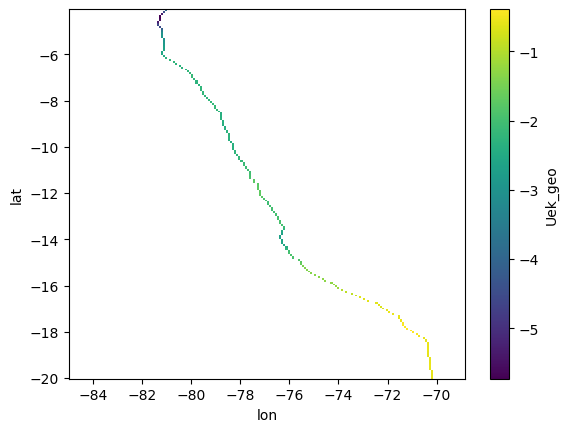

In [13]:
valid = np.isfinite(wind_coastal.Uek_geo.isel(time=0))
valid_e = valid.shift(lon=-1).fillna(False).astype(bool)
coast_mask = valid & (~valid_e)
# ssh_coast = ssh.SSH.where(coast_mask)

wind_coastal.Uek_geo.where(coast_mask).mean('time').plot()

In [14]:
# ============================================================
# 3. Find coastal and offshore boundary longitudes per latitude
# ============================================================
valid = np.isfinite(wind_coastal.Uek_geo.isel(time=0))
valid_e = valid.shift(lon=-1).fillna(False).astype(bool)
valid_w = valid.shift(lon=+1).fillna(False).astype(bool)

coast_mask = valid & (~valid_e)      # easternmost valid cell (coast)
offshore_mask = valid & (~valid_w)   # westernmost valid cell (offshore edge)

lat_all = wind_coastal.lat.values
lon_all = wind_coastal.lon.values

coast_lons = np.full(len(lat_all), np.nan)
offshore_lons = np.full(len(lat_all), np.nan)

for j in range(len(lat_all)):
    cols_e = np.where(coast_mask.isel(lat=j).values)[0]
    if len(cols_e) > 0:
        coast_lons[j] = lon_all[cols_e[0]]
    cols_w = np.where(offshore_mask.isel(lat=j).values)[0]
    if len(cols_w) > 0:
        offshore_lons[j] = lon_all[cols_w[0]]

Text(0.5, 1.0, 'coast / offshore boundary detection')

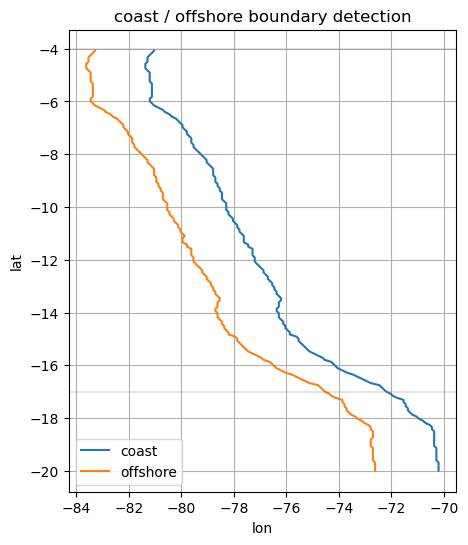

In [15]:
# Coastline diagnostic — verify coast_lons/offshore_lons look smooth.
# Jumps in coast_lons (from islands, bays, masked pixels) were the
# cause of the earlier inflated d_coast in bands 2, 11, 12.
fig, ax = plt.subplots(figsize=(5, 6))
ax.plot(coast_lons, lat_all, label='coast')
ax.plot(offshore_lons, lat_all, label='offshore')
ax.set_xlabel('lon'); ax.set_ylabel('lat')
ax.axhline(-4,  color='grey', lw=0.3)
ax.axhline(-17, color='grey', lw=0.3)
ax.legend(); ax.grid(True)
ax.set_title('coast / offshore boundary detection')

In [16]:
uek_coast = wind_coastal.Uek_geo.where(coast_mask) 
UEK_band = uek_coast.mean('lon').sel(lat=slice(-17, -5))
# Real distance using both lat AND lon of coastal points
lat_s = UEK_band.lat.values[0]
lat_n = UEK_band.lat.values[-1]

# Find the coastal lon at the south and north edges
idx_s = np.abs(lat_all - lat_s).argmin()
idx_n = np.abs(lat_all - lat_n).argmin()
lon_s = coast_lons[idx_s]
lon_n = coast_lons[idx_n]

d_coast = haversine(lat_s, lon_s, lat_n, lon_n)
# d_coast_list.append(d_)
d_coast/1000

1648.2563417570939

In [17]:
results = []
Qoff_list = []
Qn_list = []
Qs_list = []
Qcoast_list = []

lat_band_centers = []
lat_top_start = -4
lat_top_end   = -17


for lat_north in tqdm(range(lat_top_start, lat_top_end, -1)):

    lat_south = lat_north - 1

    Qdiv_band, Qoff, Qn, Qs,Qe = qdiv_vector(
        wind_coastal.Uek_geo,
        wind_coastal.Vek_geo,
        lat_south=lat_south,
        lat_north=lat_north,
        offshore_lons=offshore_lons,
        coast_lons=coast_lons,
        all_lats=lat_all,
    )

    results.append(Qdiv_band)
    Qoff_list.append(Qoff)
    Qn_list.append(Qn)
    Qs_list.append(Qs)
    Qcoast_list.append(Qe)

    lat_band_centers.append(0.5 * (lat_south + lat_north))

100%|█████████████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 29.25it/s]


In [18]:
Qdiv_all = xr.concat(results, dim='lat_band')
Qoff_all = xr.concat(Qoff_list, dim='lat_band')
Qn_all = xr.concat(Qn_list, dim='lat_band')
Qs_all = xr.concat(Qs_list, dim='lat_band')
Qe_all = xr.concat(Qcoast_list, dim='lat_band')

U_ek = Qdiv_all.assign_coords(lat_band=lat_band_centers)
Qoff_all = Qoff_all.assign_coords(lat_band=lat_band_centers)
Qn_all = Qn_all.assign_coords(lat_band=lat_band_centers)
Qs_all = Qs_all.assign_coords(lat_band=lat_band_centers)
Qe_all = Qe_all.assign_coords(lat_band=lat_band_centers)


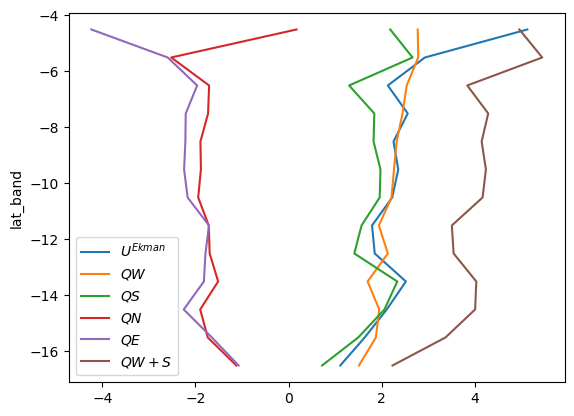

In [19]:

U_ek.mean('time').plot(y='lat_band',label='$U^{Ekman}$')
Qoff_all.mean('time').plot(y='lat_band',label='$QW$')
Qs_all.mean('time').plot(y='lat_band',label='$QS$')
Qn_all.mean('time').plot(y='lat_band',label='$QN$')
Qe_all.mean('time').plot(y='lat_band',label='$QE$')

(Qoff_all + Qs_all ).mean('time').plot(y='lat_band',label='$QW+S$')
plt.legend()

In [20]:
# This should show ~100 km difference per row
for j in range(len(lat_all)):
    if np.isfinite(coast_lons[j]) and np.isfinite(offshore_lons[j]):
        diff = np.abs(coast_lons[j] - offshore_lons[j])
        # if diff > 1.5:  # more than ~1.5 degrees = ~150 km
        print(f"lat={lat_all[j]:.1f}: coast={coast_lons[j]:.2f}, offshore={offshore_lons[j]:.2f}, diff={diff:.2f}°")

lat=-20.0: coast=-70.20, offshore=-72.62, diff=2.42°
lat=-19.9: coast=-70.20, offshore=-72.62, diff=2.42°
lat=-19.8: coast=-70.20, offshore=-72.62, diff=2.42°
lat=-19.8: coast=-70.20, offshore=-72.62, diff=2.42°
lat=-19.7: coast=-70.20, offshore=-72.62, diff=2.42°
lat=-19.6: coast=-70.28, offshore=-72.70, diff=2.42°
lat=-19.5: coast=-70.28, offshore=-72.70, diff=2.42°
lat=-19.4: coast=-70.28, offshore=-72.70, diff=2.42°
lat=-19.4: coast=-70.28, offshore=-72.70, diff=2.42°
lat=-19.3: coast=-70.28, offshore=-72.70, diff=2.42°
lat=-19.2: coast=-70.28, offshore=-72.70, diff=2.42°
lat=-19.1: coast=-70.28, offshore=-72.70, diff=2.42°
lat=-19.1: coast=-70.37, offshore=-72.78, diff=2.42°
lat=-19.0: coast=-70.37, offshore=-72.78, diff=2.42°
lat=-18.9: coast=-70.37, offshore=-72.78, diff=2.42°
lat=-18.8: coast=-70.37, offshore=-72.78, diff=2.42°
lat=-18.7: coast=-70.37, offshore=-72.70, diff=2.33°
lat=-18.7: coast=-70.37, offshore=-72.70, diff=2.33°
lat=-18.6: coast=-70.37, offshore=-72.70, diff

In [21]:
widths = []
A = 6371000.0
for j in range(len(lat_all)):
    if np.isfinite(coast_lons[j]) and np.isfinite(offshore_lons[j]):
        w = A * np.cos(np.deg2rad(lat_all[j])) * np.deg2rad(np.abs(coast_lons[j] - offshore_lons[j]))
        widths.append(w)
d_band = np.mean(widths)
print(f"Mean cross-shore width: {d_band/1000:.1f} km")

Mean cross-shore width: 249.6 km


In [22]:
A = 6371000.0
widths = np.full(len(lat_all), np.nan)
for j in range(len(lat_all)):
    if np.isfinite(coast_lons[j]) and np.isfinite(offshore_lons[j]):
        widths[j] = A * np.cos(np.deg2rad(lat_all[j])) * np.deg2rad(np.abs(coast_lons[j] - offshore_lons[j]))

widths_da = xr.DataArray(widths, dims='lat', coords={'lat': lat_all}, name='cross_shore_width')

d = lat_band_mean_(widths_da, lat_top_start=-4, lat_top_end=-17) #cross-shore distance
print(d) # L length from the coast to the offshore

100%|███████████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 3530.10it/s]

<xarray.DataArray 'cross_shore_width' (lat_band: 13)> Size: 104B
array([249401.76935861, 249020.12839815, 248564.07008193, 248034.28216051,
       247431.55927156, 246756.80006215, 246011.00396191, 252840.12970039,
       253279.71412002, 252286.73078933, 251179.14128749, 249999.96707891,
       248749.09134001])
Coordinates:
  * lat_band  (lat_band) float64 104B -4.5 -5.5 -6.5 -7.5 ... -14.5 -15.5 -16.5


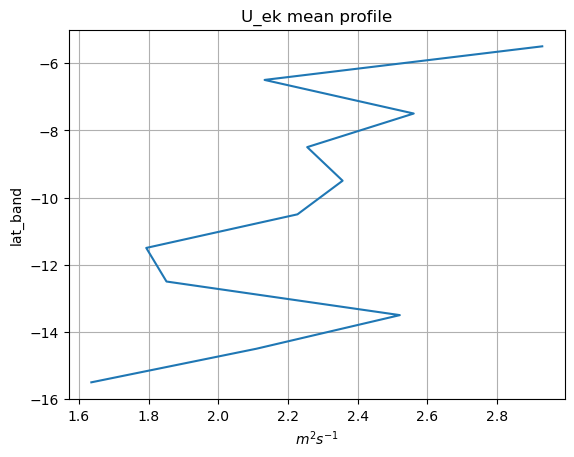

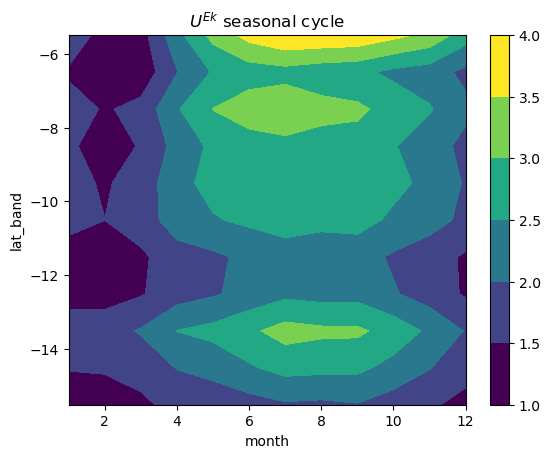

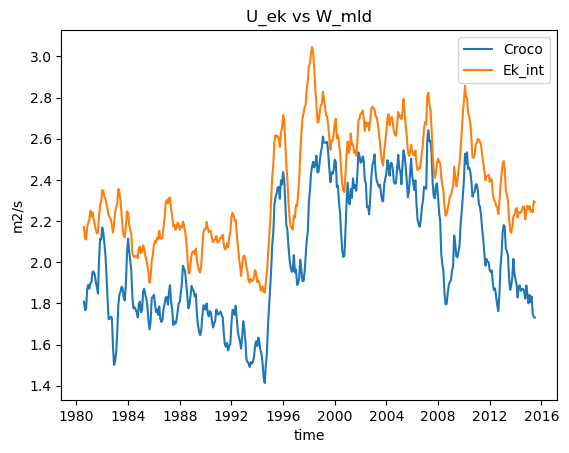

In [23]:
# ============================================================
# 6. Quick checks
# ============================================================

# Seasonality
def seasonality(data):
    return data.groupby('time.month').mean(dim='time')

# Latitudinal mean profile
U_ek.sel(lat_band=slice(-5, -16)).mean('time').rename('$m^{2}s^{-1}$').plot(y='lat_band')
plt.title('U_ek mean profile')
plt.grid(True)
plt.show()

# Seasonal Hovmöller
seasonality(U_ek).sel(lat_band=slice(-5, -16)).plot.contourf(x='month')
plt.title('$U^{Ek}$ seasonal cycle')
plt.show()

# Time series comparison with W_mld
wmld = xr.open_dataset('../W_mld_Croco.nc').compute()
wmld = wmld.where(mask).sel(lon=slice(-85, None), lat=slice(-16, -5))


(wmld*mask_km*1000).mean(dim=('lon', 'lat')).WMLD.rolling(time=13, center=True).mean().rename('m/s').plot(label='Croco')
(U_ek).mean(dim='lat_band').rolling(time=13, center=True).mean().rename('m2/s').plot(label='Ek_int')
plt.legend()
plt.title('U_ek vs W_mld')
plt.show()

## Now the Geostrophic Velocity

$
u_{\mathrm{geo}} = \frac{g}{f}\,\frac{\Delta \mathrm{SSH}}{d_{\mathrm{coast}}}
$

$
\mathbf{U}_{\mathrm{geo}} = \mathbf{u}_{\mathrm{geo}} \times \mathrm{MLD}
$

In [24]:
ssh = xr.open_dataset('../SSH.nc').compute()
ssh

<xarray.Dataset> Size: 564MB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
Data variables:
    SSH      (time, lat, lon) float32 564MB 0.212 0.212 0.2117 ... 0.0 0.0 0.0

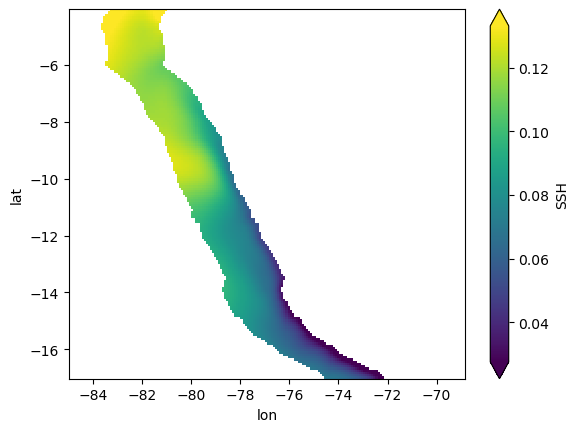

In [27]:
## SSH is in m
ssh = ssh.where(mask).sel(lon=slice(-85,None),lat=slice(lati2,lati1))
ssh.mean('time').SSH.plot(robust=True)

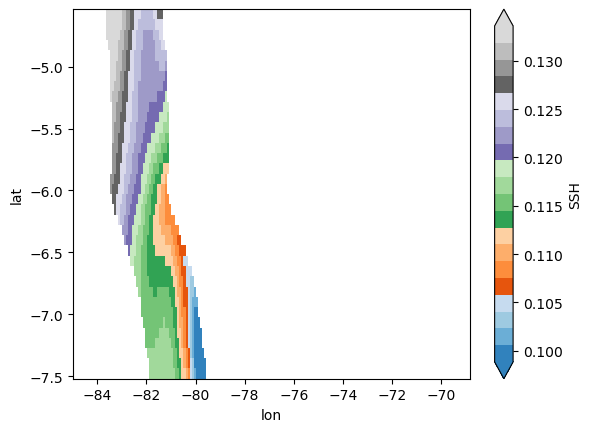

In [32]:
ssh.mean('time').SSH.sel(lat=slice(-7.5,-4.5)).plot(robust=True,cmap='tab20c')

In [28]:
valid = np.isfinite(ssh.SSH.isel(time=0))
valid_e = valid.shift(lon=-1).fillna(False).astype(bool)
coast_mask = valid & (~valid_e)
ssh_coast = ssh.SSH.where(coast_mask)

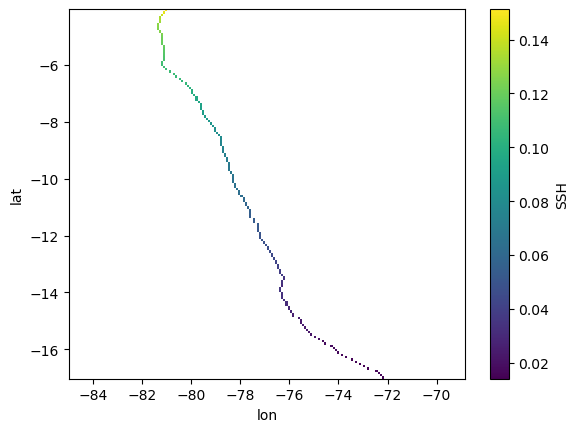

In [29]:
ssh_coast.mean('time').plot()

(array([  940., 12952., 28820., 16806.,  6225.,  1788.,   617.,   318.,
          177.,    45.]),
 array([-0.09636591, -0.0398285 ,  0.01670892,  0.07324633,  0.12978375,
         0.18632117,  0.24285857,  0.29939598,  0.3559334 ,  0.41247082,
         0.46900824]),
 <BarContainer object of 10 artists>)

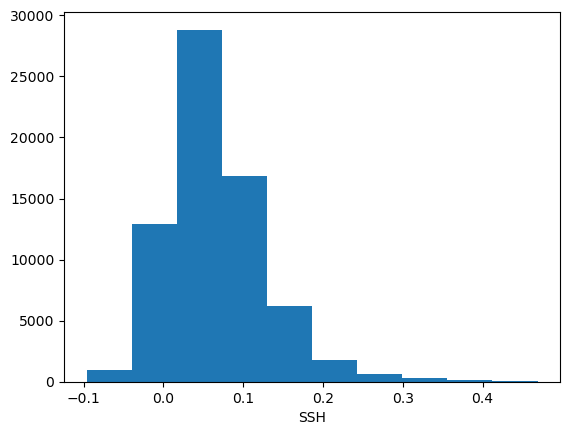

In [30]:
ssh_coast.plot()

In [27]:
lat_centers = np.arange(lat_top_start - 0.5, lat_top_end - 0.5, -1)
Omega = 7.2921e-5
f_ = 2 * Omega * np.sin(np.deg2rad(lat_centers))
f_ = xr.DataArray(f_, dims='lat_band', coords={'lat_band': lat_centers})
f_

<xarray.DataArray (lat_band: 13)> Size: 104B
array([-1.14426314e-05, -1.39783362e-05, -1.65097831e-05, -1.90362009e-05,
       -2.15568201e-05, -2.40708729e-05, -2.65775935e-05, -2.90762183e-05,
       -3.15659862e-05, -3.40461388e-05, -3.65159206e-05, -3.89745792e-05,
       -4.14213659e-05])
Coordinates:
  * lat_band  (lat_band) float64 104B -4.5 -5.5 -6.5 -7.5 ... -14.5 -15.5 -16.5

In [28]:
lat_top_start = -4
lat_top_end   = -17

delta_SSH = []
d_coast_list = []

for lat_north in tqdm(range(lat_top_start, lat_top_end, -1)):
    lat_south = lat_north - 1
    SSH_band = ssh_coast.mean('lon').sel(lat=slice(lat_south, lat_north))

    southernmost = SSH_band.isel(lat=0)
    northernmost = SSH_band.isel(lat=-1)
    delta_SSH.append(northernmost - southernmost)

    # Cumulative along-coast distance (robust to coast curvature)
    d_ = coast_path_length(lat_south, lat_north, lat_all, coast_lons)
    d_coast_list.append(d_)

ssh_ = xr.concat(delta_SSH, dim='lat_band')
ssh_ = ssh_.assign_coords(
    lat_band=np.arange(lat_top_start - 0.5, lat_top_end - 0.5, -1)
)

d_coast_ = xr.DataArray(d_coast_list, dims='lat_band',
                        coords={'lat_band': ssh_.lat_band})

# Sanity check: expect ~111 km plus a small curvature increment
for i, dc in enumerate(d_coast_list):
    lat_only = 6371000 * np.deg2rad(1.0)  # ~111 km
    print(f"Band {i}: d_coast = {dc/1000:.1f} km (vs {lat_only/1000:.1f} km lat-only, {(dc/lat_only-1)*100:+.1f}%)")

# Verify: should be positive on average (SSH increases northward along coast)
print("Mean ssh_ (should be positive):", ssh_.mean().values)

100%|█████████████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 30.51it/s]


Band 0: d_coast = 124.6 km (vs 111.2 km lat-only, +12.0%)
Band 1: d_coast = 109.1 km (vs 111.2 km lat-only, -1.9%)
Band 2: d_coast = 169.7 km (vs 111.2 km lat-only, +52.6%)
Band 3: d_coast = 127.7 km (vs 111.2 km lat-only, +14.8%)
Band 4: d_coast = 123.6 km (vs 111.2 km lat-only, +11.1%)
Band 5: d_coast = 119.4 km (vs 111.2 km lat-only, +7.4%)
Band 6: d_coast = 122.9 km (vs 111.2 km lat-only, +10.5%)
Band 7: d_coast = 138.9 km (vs 111.2 km lat-only, +24.9%)
Band 8: d_coast = 129.5 km (vs 111.2 km lat-only, +16.4%)
Band 9: d_coast = 117.8 km (vs 111.2 km lat-only, +5.9%)
Band 10: d_coast = 149.3 km (vs 111.2 km lat-only, +34.3%)
Band 11: d_coast = 176.5 km (vs 111.2 km lat-only, +58.7%)
Band 12: d_coast = 234.2 km (vs 111.2 km lat-only, +110.6%)
Mean ssh_ (should be positive): 0.009845316


In [30]:
print(d)
# print(d_coastline)

<xarray.DataArray 'cross_shore_width' (lat_band: 13)> Size: 104B
array([249401.76935861, 249020.12839815, 248564.07008193, 248034.28216051,
       247431.55927156, 246756.80006215, 246011.00396191, 252840.12970039,
       253279.71412002, 252286.73078933, 251179.14128749, 249999.96707891,
       248749.09134001])
Coordinates:
  * lat_band  (lat_band) float64 104B -4.5 -5.5 -6.5 -7.5 ... -14.5 -15.5 -16.5


In [31]:
# dy = 250*1000 # 1 degree of latitude in meters
g = 9.81

# Geostrophic cross-shore velocity from alongshore SSH gradient at the coast.
# u_geo = (g/f) * (dSSH/dy)
# Sign convention for CUTI divergence framework:
#   In SH (f<0), with SSH increasing northward (ssh_>0):
#     u_geo = (g / f_neg) * (positive) = negative → onshore (convergent)
#   This is correct: onshore geostrophic return flow reduces CUTI below U_ek.
# u_geo = (g / f_) * (ssh_ )
u_geo = (g / f_) * (ssh_ / d_coast_)

# Verify: should be negative on average (onshore)
print("Mean u_geo (should be negative):", u_geo.mean().values)

Mean u_geo (should be negative): -0.04074680118604648


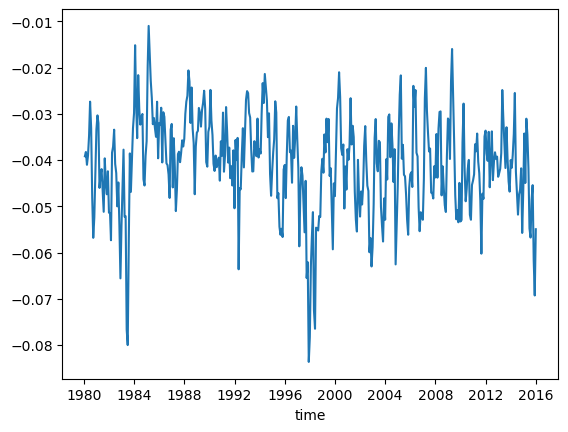

In [32]:
u_geo.mean(dim=('lat_band')).plot()

* The onshore geostrophic flow increased during EN 1997-98

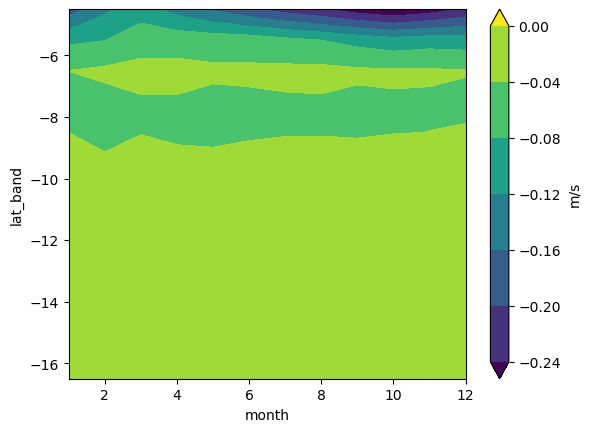

In [33]:
seasonality(u_geo.rename('m/s')).plot.contourf(robust=True)

### MLD

In [38]:
R_X = xr.open_dataset('../Rossby_radius_and_X.nc').compute()
mask = coastal_band_mask(R_X, var='R', target_width_km=mask_km)
R_X = R_X.where(mask).sel(lon=slice(-85,None),lat=slice(lati2,lati1)) 
R_lati = (R_X/1000).R.mean('lon')

# mask_rossby = coastal_band_mask_rossby(R_X, var='R', R1=R_lati)
# mask_rossby.plot()

In [39]:
MLD_ds = xr.open_dataset('../MLD.nc').compute()
MLD_ds

<xarray.Dataset> Size: 1GB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    MLD      (time, lat, lon) float64 1GB 0.9402 0.9402 1.335 ... nan nan nan

In [57]:
mask_mld = coastal_band_mask(MLD_ds, var='MLD', target_width_km=20) #93.79029711 km
MLD_ds = MLD_ds.where(mask_mld).sel(lon=slice(-85,None),lat=slice(-20,-4))
MLD_ds

<xarray.Dataset> Size: 132MB
Dimensions:  (time: 432, lat: 197, lon: 194)
Coordinates:
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 2kB -19.99 -19.92 -19.84 ... -4.245 -4.162 -4.079
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    MLD      (time, lat, lon) float64 132MB nan nan nan nan ... nan nan nan nan

* Rossby radious in Peru goes from 150 to 50km, then the MLD should be around 100km, following first deformation Rossby radious criteria by Jacox(2018)

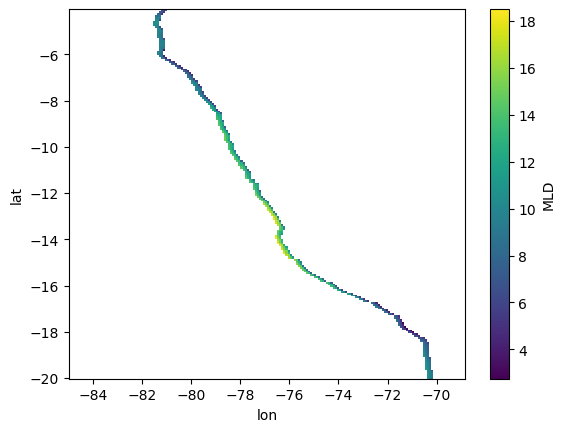

In [58]:
MLD_ds.MLD.std('time').plot()

100%|████████████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 160.46it/s]


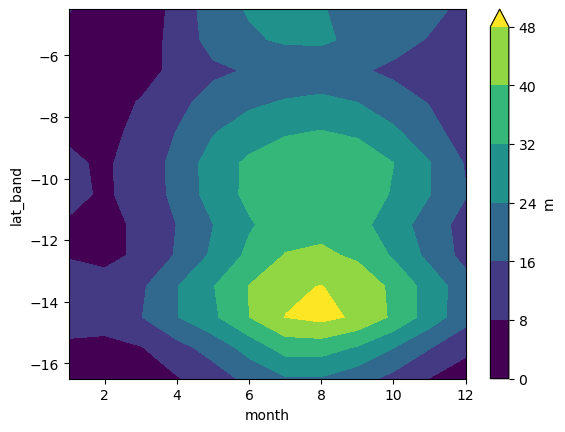

In [60]:
mld_ = lat_band_mean(MLD_ds.MLD)
# mld_
seasonality(mld_).rename('m').plot.contourf(x='month',robust=True)

## $U^{geo}$

Text(0.5, 1.0, '$U^{Geo}$')

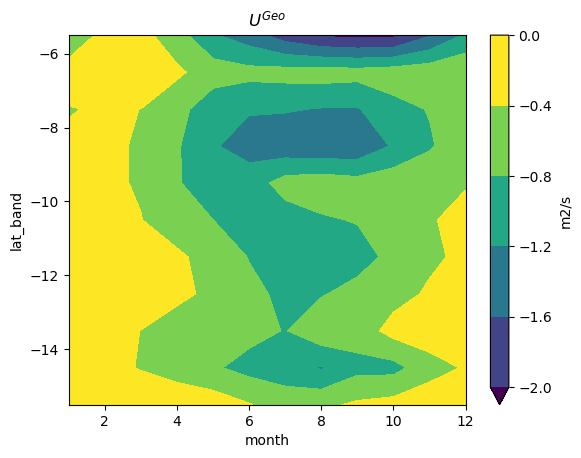

In [43]:
U_geo = (u_geo * mld_)
seasonality((u_geo * mld_)).sel(lat_band=slice(-5,-16)).rename('m2/s').plot.contourf(robust=True)
# seasonality((u_geo * mld_).mean(dim='lon')).rename('m2/s').plot.contourf(robust=True)

plt.title('$U^{Geo}$')

* Negative is onshore 

In [44]:
U_geo.sel(lat_band=slice(-5.5,-16.5))

<xarray.DataArray (lat_band: 12, time: 432)> Size: 41kB
array([[-5.01336960e-01, -4.31545824e-01, -2.68601645e-01, ...,
        -3.79891218e+00, -3.84933407e+00, -2.41302931e+00],
       [-1.35955679e-01, -1.79221869e-01, -2.88814327e-01, ...,
        -1.18881458e+00, -3.16981523e+00, -9.88889553e-01],
       [-1.01947454e-01, -2.95771005e-01, -5.27477270e-01, ...,
        -1.21074557e+00, -2.19664221e+00, -1.22983814e+00],
       ...,
       [-1.77394043e-01, -2.68605577e-01, -2.98504688e-01, ...,
        -1.27706264e+00, -1.26588670e+00, -9.79406975e-01],
       [-5.64611249e-03, -3.57974159e-02, -3.10862589e-02, ...,
        -3.14676002e-01, -1.36975897e-01, -7.49058448e-02],
       [-2.37017762e-03,  1.05506915e-02, -5.10449256e-03, ...,
        -5.29851383e-03, -1.78656048e-01, -3.26636116e-02]])
Coordinates:
  * lat_band  (lat_band) float64 96B -5.5 -6.5 -7.5 -8.5 ... -14.5 -15.5 -16.5
  * time      (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31

## CUTI

$CUTI$ = $U^{Ek}$ + $U^{Geo}$

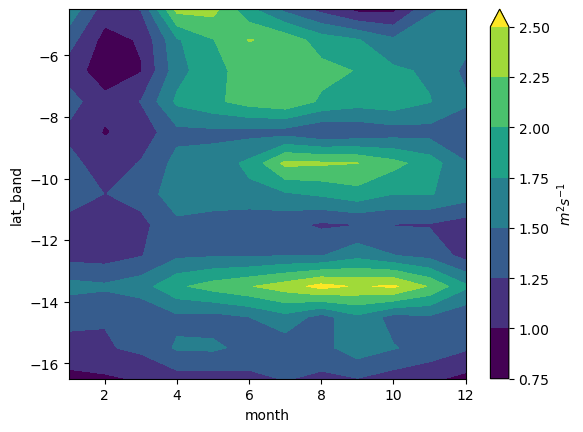

In [51]:
CUTI = (U_ek) + (U_geo)#m2/s

seasonality((CUTI)).sel(lat_band=slice(lati1,lati2)).rename('$m^2s^{-1}$').plot.contourf(robust=True)

Text(0.5, 1.0, '$CUTI$')

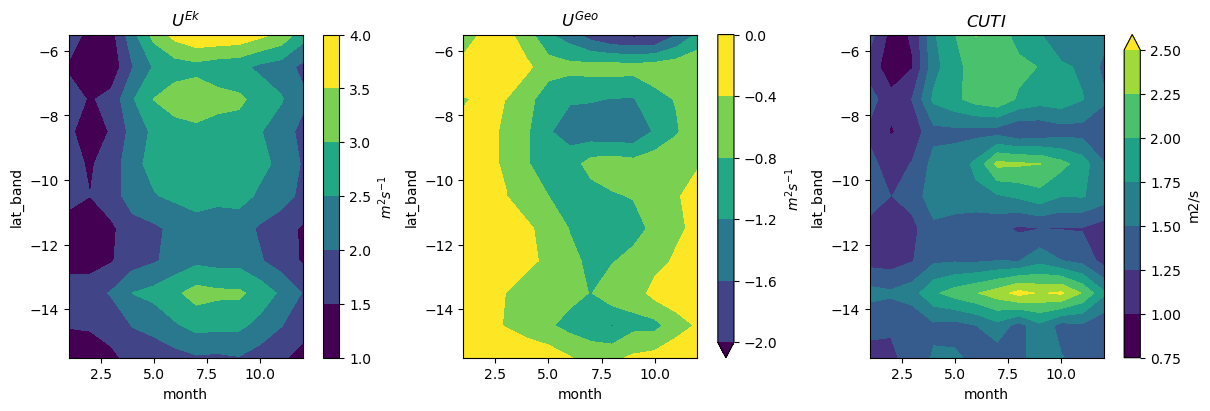

In [52]:
fig,ax = plt.subplots(1,3,figsize=(12,4),constrained_layout=True)

seasonality(U_ek).sel(lat_band=slice(-5,-16)).rename('$m^2s^{-1}$').plot.contourf(
    x='month',robust=True,ax=ax[0])
seasonality(U_geo).sel(lat_band=slice(-5,-16)).rename('$m^2s^{-1}$').plot.contourf(
    x='month',robust=True,ax=ax[1])
seasonality(CUTI).sel(lat_band=slice(-5,-16)).rename('m2/s').plot.contourf(
    x='month',robust=True,ax=ax[2])

ax[0].set_title('$U^{Ek}$')
ax[1].set_title('$U^{Geo}$')
ax[2].set_title('$CUTI$')

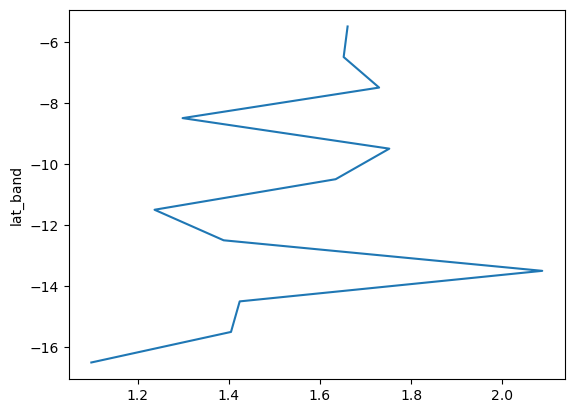

In [53]:
(CUTI).mean('time').sel(lat_band=slice(-5,-16.5)).plot(y='lat_band')

# (CUTI/d).mean(dim=('lon','time')).plot(y='lat_band')

In [54]:
wmld2 = xr.open_dataset('../W_mld_Croco.nc').compute()
wmld2 = wmld2.where(mask).sel(lon=slice(-85,None),lat=slice(lati2,lati1))
wmld2

<xarray.Dataset> Size: 107MB
Dimensions:  (time: 432, lat: 159, lon: 194)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 1kB -16.99 -16.91 -16.83 ... -4.245 -4.162 -4.079
Data variables:
    WMLD     (time, lat, lon) float64 107MB nan nan nan nan ... nan nan nan nan

In [55]:
wmld__ = transport_band(wmld2.fillna(0).WMLD,
    lat_top_start=-4,
    lat_top_end=-17,
)

100%|████████████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 105.48it/s]


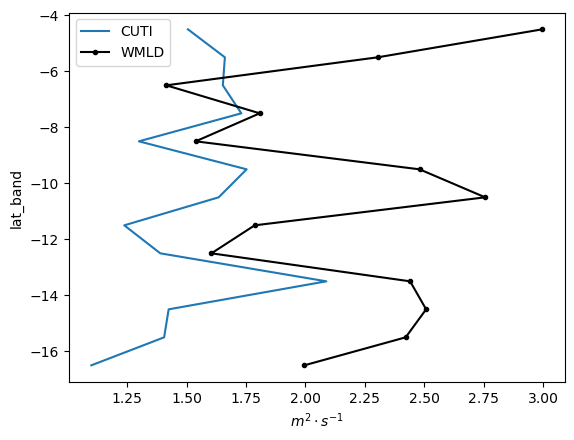

In [62]:
R = 6371000.0
# convert degree spacing to radians
dlon = np.deg2rad(1/12)
# latitude in radians (2D or 1D broadcastable)
lat_rad = np.deg2rad(wmld['lat'])
# dx (meters), varies with latitude
dx = R * np.cos(lat_rad) * dlon

##### 
# (wmld2.fillna(0) * dx).sum(dim='lon').mean('time').WMLD.rolling(lat=13,center=True).mean().plot(y='lat',color='gray')
CUTI.mean(dim=('time')).plot(y='lat_band',label='CUTI')
wmld__.mean(dim=('time')).rename('$m^{2} \cdot s^{-1}$').plot(y='lat_band',label='WMLD',color='black',marker='.')
plt.legend()

In [63]:
wmld_ = lat_band_mean(wmld2.WMLD,
    lat_top_start=-4,
    lat_top_end=-17,
)

100%|████████████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 141.91it/s]


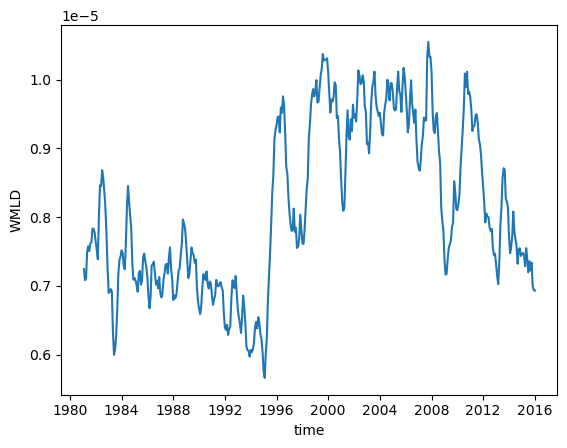

In [64]:
wmld_.sel(lat_band=slice(-5,-16)).mean(dim=('lat_band')).rolling(time=13).mean().plot()

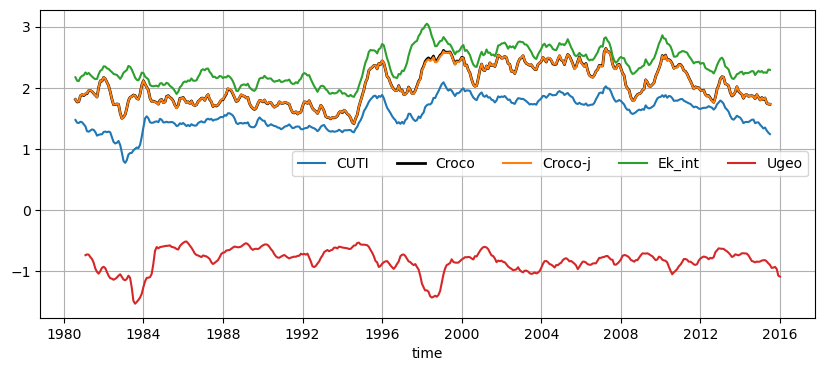

In [65]:
(CUTI).sel(lat_band=slice(-5,-16)).mean(dim=('lat_band')).rolling(time=13,center=True).mean().plot(label='CUTI',figsize=(10,4))
(wmld*250*1000).sel(lat=slice(-16,-5)).mean(dim=('lon','lat')).WMLD.rolling(time=13,center=True).mean().rename('m/s').plot(label='Croco',linewidth=2,color='black')
(wmld_*250*1000).sel(lat_band=slice(-5,-16)).mean(dim=('lat_band')).rolling(time=13,center=True).mean().rename('m/s').plot(label='Croco-j')

(((U_ek)).mean(dim='lat_band')).rolling(time=13,center=True).mean().rename('m/s').plot(label='Ek_int')
(U_geo).mean(dim=('lat_band')).rolling(time=13).mean().plot(label='Ugeo')

plt.legend(ncols=6,loc='best')
plt.grid()

### Seasonality

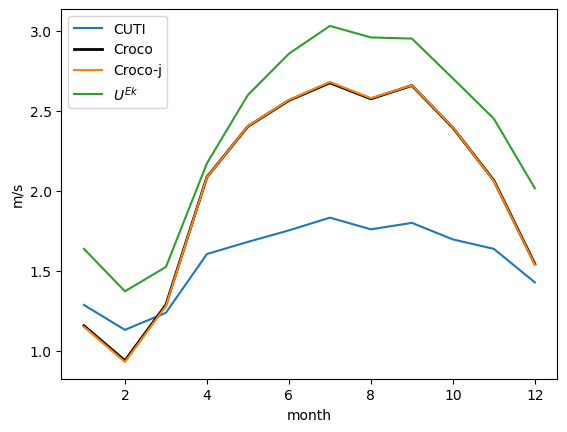

In [66]:
seasonality((CUTI)).sel(lat_band=slice(-5,-16)).mean(dim=('lat_band')).plot(label='CUTI')
seasonality(wmld*250*1000).sel(lat=slice(-16,-5)).mean(dim=('lon','lat')).WMLD.rename('m/s').plot(label='Croco',linewidth=2,color='black')
seasonality(wmld_*250*1000).sel(lat_band=slice(-5,-16)).mean(dim=('lat_band')).rename('m/s').plot(label='Croco-j')

(seasonality(U_ek)).mean(dim='lat_band').rename('m/s').plot(label='$U^{Ek}$')
# seasonality((U_geo/d).mean(dim=('lat_band','lon'))).plot(label='$U^{Geo}$')
# seasonality((ds.Uekman_Crossshore*-1/d).mean(dim=('lon','lat'))).plot(label='Uekman_crosshore')

plt.legend()

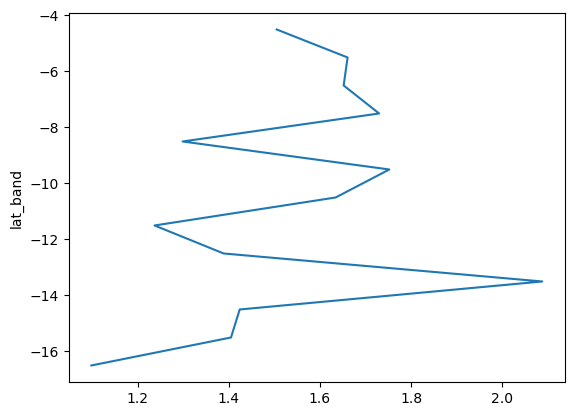

In [67]:
# (wmld*60*60*24).mean('time').WMLD.plot.contourf(robust=True,vmin=-5, vmax=5, cmap='RdBu_r',levels)
(CUTI).mean('time').plot(y='lat_band')

In [ ]:
nitrogen = xr.open_dataset('../Nitrogen.nc').compute()
nitrogen

In [ ]:
N = nitrogen.where(mask_mld).sel(lon=slice(-85,None),lat=slice(lati2,lati1))
N

In [ ]:
N_ = lat_band_mean(N.TN_mld,
    lat_top_start=-4,
    lat_top_end=-17,
)
N_

In [ ]:
fig,ax = plt.subplots(1,2,figsize=(10,4))
CUTI.isel(time=0).plot(ax=ax[0],y='lat_band')
N_.rename('N at MLD').isel(time=0).plot(ax=ax[1],y='lat_band')

In [ ]:
BEUTI = (N_ * CUTI)
(BEUTI).mean('time').plot(y='lat_band')

In [ ]:
fig, ax1 = plt.subplots(figsize=(12, 5))

# Left axis
(CUTI).sel(lat_band=slice(-5,-16)).mean(dim=('lat_band')).rolling(time=13,center=True).mean().plot(ax=ax1, label='CUTI', color='Blue')
# (CUTI/d).sel(lat_band=slice(-5,-16)).mean(dim=('lon','lat_band')).rolling(time=13).mean().plot(label='CUTI')

# (wmld*250*1000).mean(dim=('lon','lat')).WMLD.rolling(time=13,center=True).mean().rename('m/s').plot(ax=ax1, label='Croco', linewidth=2, color='black')
(wmld_*250*1000).sel(lat_band=slice(-5,-16)).mean(dim=('lat_band')).rolling(time=13,center=True).mean().rename('m/s').plot(ax=ax1, label='Croco-j',color='black')
ax1.set_ylabel('m/s')
ax1.legend(loc='upper left')

# Right axis for BEUTI
ax2 = ax1.twinx()
BEUTI.sel(lat_band=slice(-5,-16)).mean(dim=('lat_band')).rolling(time=13,center=True).mean().plot(ax=ax2, label='BEUTI', color='orange')
ax2.set_ylabel('BEUTI')
ax2.legend(loc='upper right')

plt.tight_layout()

In [ ]:
N2 = nitrogen.where(mask_mld).sel(lon=slice(-85,None),lat=slice(-16,-5))

In [ ]:
seasonality(N2.TN_surf).mean(dim=('lat','lon')).plot(label='Surface Nitro')
seasonality(N2.TN_mld).mean(dim=('lat','lon')).plot(label='MLD Nitro')
plt.legend()
plt.title('Nitrogen Cycle')

In [ ]:
fig, (ax1, ax3) = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

# --- Top panel ---
seasonality(CUTI).sel(lat_band=slice(-5,-16)).mean(dim=('lat_band')).plot(ax=ax1, label='CUTI', color='blue')
# seasonality(wmld*250*1000).sel(lat=slice(-5,-16)).mean(dim=('lon','lat')).WMLD.rename('m/s').plot(ax=ax1, label='Croco', linewidth=2, color='black')
seasonality(wmld_*250*1000).sel(lat_band=slice(-5,-16)).mean(dim=('lat_band')).rename('m/s').plot(ax=ax1, label='Croco-j', linewidth=2, color='black')
ax1.set_ylabel('m2/s')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
seasonality(BEUTI.sel(lat_band=slice(-5,-16)).mean(dim=('lat_band'))).plot(ax=ax2, label='BEUTI', color='orange')
ax2.set_ylabel('BEUTI')
ax2.legend(loc='upper right')

# --- Bottom panel ---
seasonality(N2.TN_surf).mean(dim=('lat','lon')).plot(ax=ax3, label='Surface Nitro')
seasonality(N2.TN_mld).mean(dim=('lat','lon')).plot(ax=ax3, label='MLD Nitro')
ax3.legend()
ax3.set_title('Nitrogen Cycle')

plt.tight_layout()

* Nitrogen input follows the upwelling season, BEUTI amplifies CUTI in seasonal scales

In [ ]:
wmld_ = wmld_.rename('Croco_j')
wmld_

In [ ]:
CUTI = CUTI.to_dataset(name='CUTI')
# CUTI

In [ ]:
CUTI['BEUTI'] = BEUTI
CUTI['UGEO'] = U_geo
CUTI['u_geo'] = u_geo
CUTI['U_ek'] = U_ek
CUTI['N_mld'] = N_
CUTI['CROCO_j'] = wmld_

In [ ]:
fig,ax = plt.subplots(2,1,figsize=(10,7))
CUTI.CUTI.plot.contourf(robust=True,ax=ax[0])
CUTI.BEUTI.plot.contourf(robust=True,ax=ax[1])

In [ ]:
CUTI['cross_shore_distance'] = d
CUTI

In [ ]:
seasonality(CUTI).CROCO_j.sel(lat_band=slice(-5,-16)).mean(dim=('lat_band')).plot()
# seasonality(wmld).sel(lat=slice(-16,-5)).mean(dim=('lon','lat')).WMLD.rename('m2/s').plot(label='Croco',linewidth=2,color='black')


In [ ]:
(CUTI*250*1000).CROCO_j.sel(lat_band=slice(-5,-16)).mean('time').plot(y='lat_band')
(wmld*250*1000).sel(lat=slice(-16,-5)).mean(dim=('lon','time')).WMLD.rolling(lat=13,center=True).mean().plot(y='lat')
CUTI.CUTI.sel(lat_band=slice(-5,-16)).mean('time').plot(y='lat_band')